# Run one VQE Example

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from typing import Sequence
import pyscf
from glob import glob



from qiskit import QuantumCircuit, QuantumRegister

from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from tqdm import tqdm
from ansatzmap import get_zigzag_physical_layout


from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, Estimator

import ffsim

from DDLUCJ import DDLUCJ, GrabAmps


In [2]:
BasisDirs=glob('data/*')
energyDF=pd.read_csv("../../../classical/energies.csv",index_col=0)
moldf = pd.read_csv('molecules.csv')
activespacedf = pd.read_csv("active_spaces.csv")

In [3]:
# Set up water
xyz = "../../../classical/structures/water183.xyz"
name='water'
NFroz=0
Norb=7
Nelec=10
basisset='STO-3G'

refEnergyDF = energyDF[(energyDF['Molecule']==name)&(energyDF['Basis Set']==basisset)]

In [4]:
refEnergyDF

,Basis Set,Molecule,Method,Energy
0,STO-3G,water,HF,-74.960552
1,STO-3G,water,CCSD,-75.009350
2,STO-3G,water,CASCI,-75.009479
3,STO-3G,water,SHCI,-75.009474


In [5]:
mol = pyscf.gto.Mole()
mol.build(atom=xyz, basis=basisset)

# Get molecular data and Hamiltonian
scf = pyscf.scf.RHF(mol).run()
mol_data = ffsim.MolecularData.from_scf(scf)
mol_hamiltonian = mol_data.hamiltonian
# Convert MolecularHamiltonian to FermionOperator
ferm_op = ffsim.fermion_operator(mol_hamiltonian)

Hamiltonian = ffsim.qiskit.jordan_wigner(ferm_op)

converged SCF energy = -74.9605519518539


In [6]:
# Define active space
active_space = range(NFroz, NFroz+Norb)
 
# Get molecular integrals

cas = pyscf.mcscf.CASCI(scf, Norb,Nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), Norb)


In [7]:
def BuildCircuit(T1Tensor,T2Tensor,Layers):
    alpha_alpha_indices = [(p, p + 1) for p in range(Norb - 1)]
    alpha_beta_indices = [(p, p) for p in range(0, Norb, 4)]
     
     
    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=T2Tensor,
        t1=T1Tensor,
        n_reps=Layers,
        interaction_pairs=(alpha_alpha_indices, alpha_beta_indices)
    )
    
    nelec = (Nelec//2, Nelec//2)
     
    # create an empty quantum circuit
    qubits = QuantumRegister(2 * Norb, name="q")
    circuit = QuantumCircuit(qubits)
     
    # prepare Hartree-Fock state as the reference state and append it to the quantum circuit
    circuit.append(ffsim.qiskit.PrepareHartreeFockJW(Norb, nelec), qubits)
     
    # apply the UCJ operator to the reference state
    circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
    # circuit.measure_all()
    return circuit

In [8]:
def cost_func(
    x, 
    t1_shape, 
    t2_shape, 
    t1_size,
    Layers,
    hamiltonian: SparsePauliOp,
    estimator: BaseEstimatorV2,
) -> float:
    """Ground state energy evaluation."""
    T1Tensor = x[:t1_size].reshape(t1_shape)
    T2Tensor = x[t1_size:].reshape(t2_shape)
    
    ansatz=BuildCircuit(T1Tensor,T2Tensor,Layers)
    return (
        estimator.run([(ansatz, hamiltonian)])
        .result()[0]
        .data.evs
    )
    
def visualize_results(results):
    plt.plot(results["cost_history"], lw=2)
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.show()


def build_callback(t1_shape, t2_shape, t1_size,Layers, 
                   circuit, hamiltonian, estimator, callback_dict):
    def callback(x):
        T1Tensor = x[:t1_size].reshape(t1_shape)
        T2Tensor = x[t1_size:].reshape(t2_shape)
        
        ansatz=BuildCircuit(T1Tensor,T2Tensor,Layers)        
        # Keep track of the number of iterations
        callback_dict["iters"] += 1
        # Compute the value of the cost function at the current vector
        current_cost = (
            estimator.run([(ansatz, hamiltonian)])
            .result()[0]
            .data.evs
        )
        callback_dict["cost_history"].append(current_cost)
        # Print to screen on single line
        print(
            "Iters. done: {} [Current cost: {}]".format(
                callback_dict["iters"], current_cost
            ),
            end="\r",
            flush=True,
        )

    return callback

In [9]:
# # Generate a pass manager without providing a backend
# from qiskit.transpiler import generate_preset_pass_manager
# circuit = BuildCircuit(t1,t2,10)

# pm = generate_preset_pass_manager(optimization_level=1)
# isa_circuit = pm.run(circuit)
# isa_Hamiltonian = Hamiltonian.apply_layout(isa_circuit.layout)


# job = estimator.run([(circuit, Hamiltonian)])
# result = job.result()
# print(f" > Result class: {type(result)}")


# print(f" > Expectation value: {result[0].data.evs}")
# print(f" > Metadata: {result[0].metadata}")



In [10]:
from qiskit.primitives import StatevectorEstimator
 
estimator = StatevectorEstimator()

E(CCSD) = -75.00934953447732  E_corr = -0.04879758262339531
(10, -74.97043757868023, 3)t: -74.97043757868023]


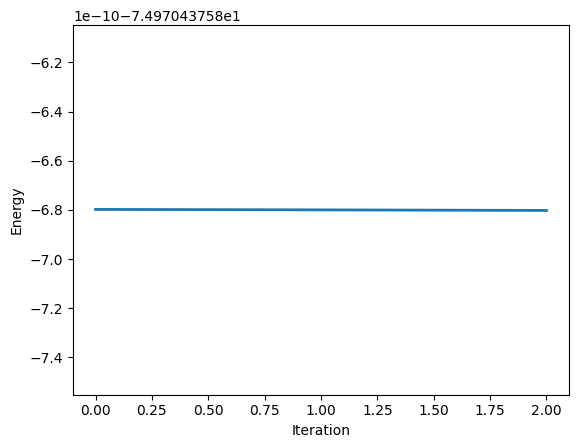

In [11]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

t1_shape=t1.shape
t2_shape=t2.shape
t1_size=t1.size
x0=np.hstack([t1.flatten(),t2.flatten()])
energies = []
Layers = 10
initcircuit=BuildCircuit(t1,t2,Layers)

callback_dict = {"iters": 0,"cost_history": []}

callback = build_callback(t1_shape, t2_shape, t1_size,Layers,
    initcircuit, Hamiltonian, estimator, callback_dict
)
res = minimize(
    cost_func,
    x0=x0,
    args=(t1_shape, t2_shape, t1_size,Layers, Hamiltonian, estimator),
    method="BFGS",
    callback=callback,
    # tol=1e-8,
    # options={"maxiter": 1000},
)
print((Layers,res.fun,callback_dict['iters']))
# energies.append((Layers,res.fun,callback_dict['iters']))
visualize_results(callback_dict)

In [12]:
(exactDF['Energy'] - refEnergyDF.loc[refEnergyDF["Method"] == "CASCI",:]['Energy'].values) * 1e3

NameError: name 'exactDF' is not defined

In [ ]:
plt.hlines(res.fun,0,5,label='LUCJ')
plt.hlines(refEnergyDF.loc[refEnergyDF["Method"] == "SHCI",:]['Energy'].values,0,5,color='orange',linestyles='-.',label='SHCI')
plt.hlines(refEnergyDF.loc[refEnergyDF["Method"] == "CASCI",:]['Energy'].values,0,5,color='r',linestyles='-.',label='CASCI')
plt.hlines(refEnergyDF.loc[refEnergyDF["Method"] == "CCSD",:]['Energy'].values,0,5,color='b',linestyles='--',label='CCSD')
plt.hlines(refEnergyDF.loc[refEnergyDF["Method"] == "HF",:]['Energy'].values,0,5,color='g',linestyles='--',label='HF')
# plt.xlim(0,len(exactDF))
plt.ylabel(r"Energy ($E_{\mathrm{h}}$)")
plt.legend()
plt.show()

In [ ]:
ampDict = GrabAmps(name,basisset)

In [ ]:
energies = []
for k,v in ampDict.items():
    print(k)
    t1,t2 = v

    t1_shape=t1.shape
    t2_shape=t2.shape
    t1_size=t1.size
    x0=np.hstack([t1.flatten(),t2.flatten()])
    
    for Layers in range(1,6):
        initcircuit=BuildCircuit(t1,t2,Layers)
    
        callback_dict = {"iters": 0,"cost_history": []}
        
        callback = build_callback(t1_shape, t2_shape, t1_size,Layers,
            initcircuit, Hamiltonian, estimator, callback_dict
        )
        res = minimize(
            cost_func,
            x0=x0,
            args=(t1_shape, t2_shape, t1_size,Layers, Hamiltonian, estimator),
            method="cobyla",
            callback=callback
            # options={"maxiter": 100},
        )
        print((k,Layers,res.fun,callback_dict['iters']))
        energies.append((k,Layers,res.fun,callback_dict['iters']))
        visualize_results(callback_dict)

In [ ]:
plt.hlines(scf.e_tot - CASCI.e_tot,0,300,color='g',linestyle='-.',label='HF')
plt.hlines(CASCI.e_tot - CASCI.e_tot,0,300,color='g',linestyle='-.',label='CASCI')
plt.hlines(ccsd.e_tot - CASCI.e_tot,0,300,color='r',linestyles='--',label='CCSD')
plt.plot(callback_dict["cost_history"]  - CASCI.e_tot , lw=2,label=f"LUCJ(L={Layers})")
plt.xlabel("Iteration")
plt.ylabel(r"Deviation ($E_{\mathrm{h}}$)")
# plt.yscale('log')
plt.xlim(-1,callback_dict['iters']+1)
plt.legend()
plt.show()